In [49]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from wordcloud import WordCloud

from  sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

#descobre automaticamente raiz projeto

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

#importar funções da v1
from src.features_v1 import FEATURES_V1, limpar_texto, extrair_features_v1

print("Raiz do projeto:", ROOT)
print("Features V1:", FEATURES_V1)

Raiz do projeto: d:\PROJETO GB\Assinaturadigital-1
Features V1: ['avg_word_length', 'num_words', 'num_unique_words', 'unique_ratio', 'num_chars', 'num_punctuation', 'num_uppercase', 'num_emojis', 'num_hashtags', 'num_mentions', 'num_exclamation', 'num_question']


In [50]:
df = pd.read_csv(ROOT / "data" / "tweet.csv")

df.head()

,Name,Tweet description
0,Barack Obama,We're seeing the fastest rise in sea-levels in...
1,Barack Obama,RT @WhiteHouse: Watch @POTUS and @FLOTUS share...
2,Barack Obama,See what editorial boards are saying about Sen...
3,Barack Obama,President Obama is at the @CopernicusCtr in Ch...
4,Barack Obama,LIVE: President Obama is answering questions f...


In [51]:
df.shape

(18680, 2)

In [52]:
df.columns

Index(['Name', 'Tweet description'], dtype='str')

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18680 entries, 0 to 18679
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Name               18680 non-null  str  
 1   Tweet description  18680 non-null  str  
dtypes: str(2)
memory usage: 2.5 MB


In [54]:
df.isnull().sum()

Name                 0
Tweet description    0
dtype: int64

## Definição do problema de ML

Este projeto trata de um problema de classificação supervisionada multiclasse.

-cada entrada é um tweet.
-a variável alvo ('y') é o autor do tweet, presente na coluna 'name".
-os previsores ('X') são atributos numéricos extraídos do texto.
o objetivo é prever o autor provável de um novo texto com base em características estilométricas.

In [55]:
df["Name"].value_counts()

Name
Barack Obama           2585
Neil deGrasse Tyson    2525
Ellen DeGeneres        2457
Sebastian Ruder        2374
KATY PERRY             2326
Elon Musk              2232
Kim Kardashian West    2149
Cristiano Ronaldo      2032
Name: count, dtype: int64

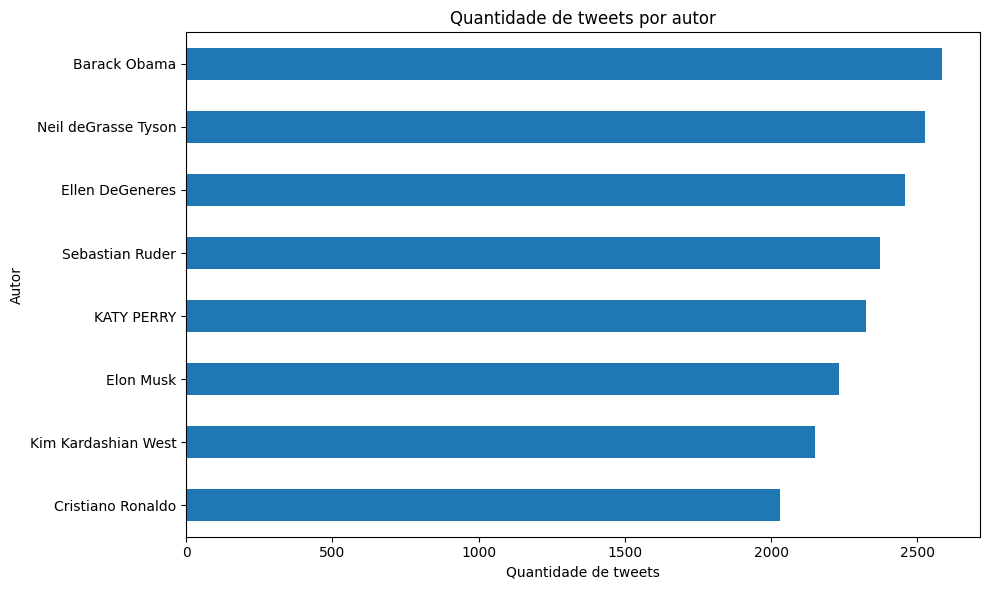

In [56]:
plt.figure(figsize=(10, 6))
df["Name"].value_counts().sort_values().plot(kind="barh")
plt.title("Quantidade de tweets por autor")
plt.xlabel("Quantidade de tweets")
plt.ylabel("Autor")
plt.tight_layout()
plt.show()

In [57]:
df["num_words_raw"] = df["Tweet description"].astype(str).apply(lambda x: len(x.split()))

df[["Name", "Tweet description", "num_words_raw"]].head()

,Name,Tweet description,num_words_raw
0,Barack Obama,We're seeing the fastest rise in sea-levels in...,13
1,Barack Obama,RT @WhiteHouse: Watch @POTUS and @FLOTUS share...,16
2,Barack Obama,See what editorial boards are saying about Sen...,18
3,Barack Obama,President Obama is at the @CopernicusCtr in Ch...,18
4,Barack Obama,LIVE: President Obama is answering questions f...,13


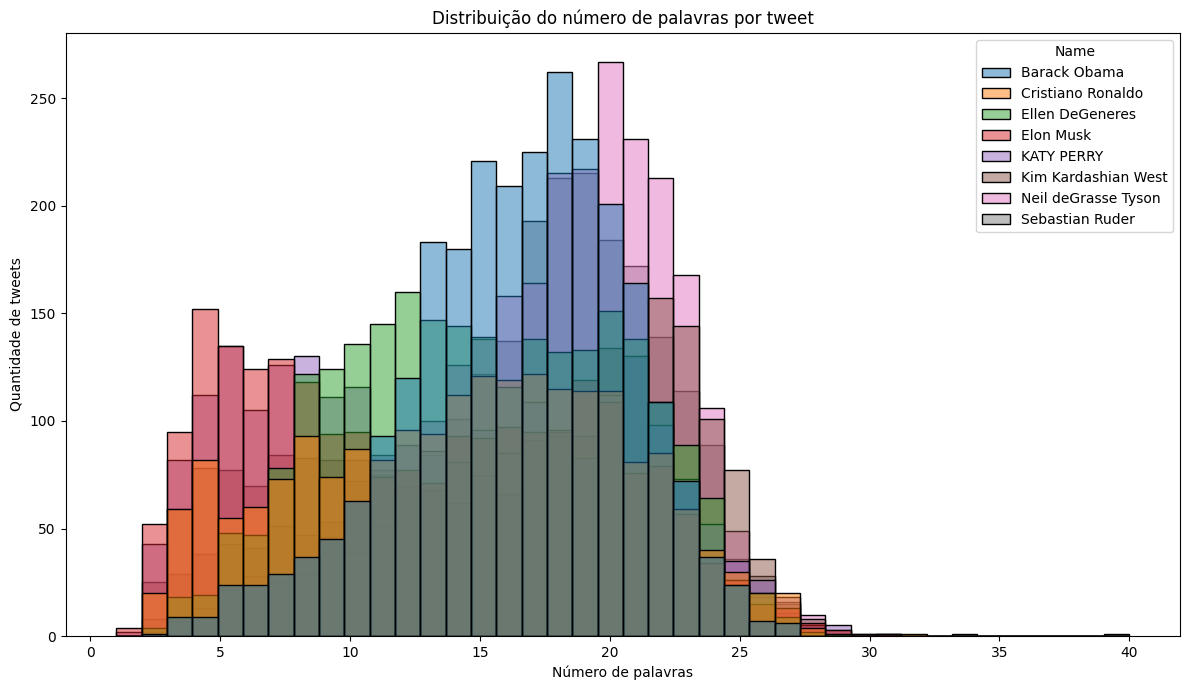

In [58]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x="num_words_raw", hue="Name", bins=40, kde=False)
plt.title("Distribuição do número de palavras por tweet")
plt.xlabel("Número de palavras")
plt.ylabel("Quantidade de tweets")
plt.tight_layout()
plt.show()

## WordCloud

A wordcloud foi usada apenas como ferramente de análise exploratória.

Ela mostra visualmente as palavras mais frequentes nos textos. Quanto maior a palavra aparece, maior foi sua frequência no conjunto analisado.

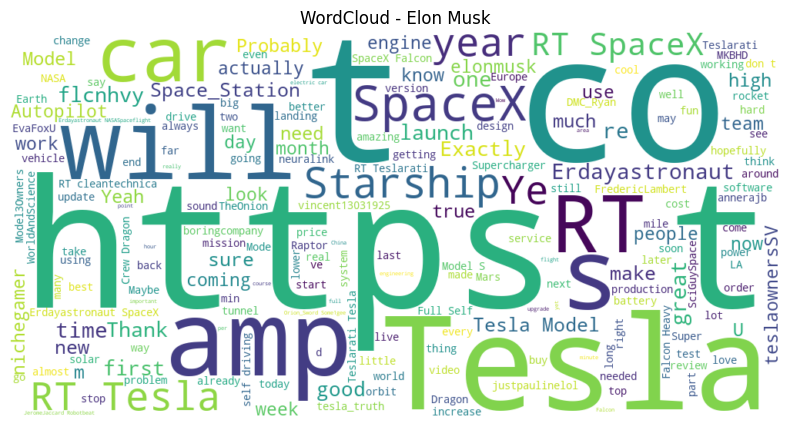

In [59]:
autor = "Elon Musk"
texto = " ".join(df[df["Name"] == autor]["Tweet description"].astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(texto)

plt.figure (figsize=(12, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"WordCloud - {autor}")
plt.show()


In [60]:
print("Funções carregadas de src/features_v1.py:")
print("- limpar_texto")
print("- extrair_features_v1")

Funções carregadas de src/features_v1.py:
- limpar_texto
- extrair_features_v1


In [61]:
df["tweet_limpo"] = df["Tweet description"].apply(limpar_texto)

df[["Tweet description", "tweet_limpo"]].head()

,Tweet description,tweet_limpo
0,We're seeing the fastest rise in sea-levels in...,We're seeing the fastest rise in sea-levels in...
1,RT @WhiteHouse: Watch @POTUS and @FLOTUS share...,RT : Watch and share their favorite Olympic me...
2,See what editorial boards are saying about Sen...,See what editorial boards are saying about Sen...
3,President Obama is at the @CopernicusCtr in Ch...,President Obama is at the in Chicago speaking ...
4,LIVE: President Obama is answering questions f...,LIVE: President Obama is answering questions f...


In [62]:
df["num_words_clean"] = df["tweet_limpo"].apply(lambda x: len(x.split()))

df[["tweet_limpo", "num_words_clean"]].head()

,tweet_limpo,num_words_clean
0,We're seeing the fastest rise in sea-levels in...,12
1,RT : Watch and share their favorite Olympic me...,12
2,See what editorial boards are saying about Sen...,17
3,President Obama is at the in Chicago speaking ...,16
4,LIVE: President Obama is answering questions f...,12


In [63]:
antes = df.shape[0]

df = df[df["num_words_clean"] >= 5].copy()

depois = df.shape[0]

print("Linhas antes:", antes)
print("linhas depois", depois)
print("Removidas:", antes - depois)

Linhas antes: 18680
linhas depois 16912
Removidas: 1768


In [64]:
#def contar_emojis(texto):
   # return sum(1 for char in str(texto) if char in emoji.EMOJI_DATA)

#def extrair_features(texto_original):
    texto_original = str(texto_original)
    texto_limpo = limpar_texto(texto_original)

    palavras = texto_limpo.split()
    total_palavras = len(palavras)

    if total_palavras == 0:
        total_palavras = 1

    tamanhos_palavras = [len(p) for p in palavras]

    avg_word_length = np.mean(tamanhos_palavras) if tamanhos_palavras else 0
    num_words = len(palavras)
    num_unique_words = len(set(palavras))
    unique_ratio = num_unique_words / total_palavras
    num_chars = len(texto_limpo)

    num_punctuation = sum(1 for c in texto_original if c in ".,;:")
    letras = [c for c in texto_original if c.isalpha()]
    num_uppercase = sum(1 for c in letras if c.isupper()) / len(letras) if letras else 0

    num_emojis = contar_emojis(texto_original)
    num_hashtags = len(re.findall(r"#\w+", texto_original))
    num_mentions = len(re.findall(r"@\w+", texto_original))
    num_exclamation = texto_original.count("!")
    num_question = texto_original.count("?")

    return {
        "avg_word_length": avg_word_length,
        "num_words": num_words,
        "num_unique_words": num_unique_words,
        "unique_ratio": unique_ratio,
        "num_chars": num_chars,
        "num_punctuation": num_punctuation,
        "num_uppercase": num_uppercase,
        "num_emojis": num_emojis,
        "num_hashtags": num_hashtags,
        "num_mentions": num_mentions,
        "num_exclamation": num_exclamation,
        "num_question": num_question
    }

In [65]:
features_df = df["Tweet description"].apply(extrair_features_v1).apply(pd.Series)

#para que as colunas fiquem na mesma ordem usada no app.py
features_df = features_df[FEATURES_V1]

features_df.head()

,avg_word_length,num_words,num_unique_words,unique_ratio,num_chars,num_punctuation,num_uppercase,num_emojis,num_hashtags,num_mentions,num_exclamation,num_question
0,5.666667,12.0,11.0,0.916667,79.0,10.0,11.0,0.0,1.0,0.0,0.0,0.0
1,5.250000,12.0,12.0,1.000000,74.0,16.0,25.0,0.0,1.0,3.0,0.0,0.0
2,5.176471,17.0,17.0,1.000000,104.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0
3,5.000000,16.0,15.0,0.937500,95.0,12.0,16.0,0.0,1.0,1.0,0.0,0.0
4,5.416667,12.0,11.0,0.916667,76.0,13.0,15.0,0.0,1.0,3.0,0.0,0.0


In [66]:
dados_modelo = pd.concat(
    [
        features_df.reset_index(drop=True),
        df["Name"].reset_index(drop=True)
    ],
    axis=1
)

dados_modelo.head()

,avg_word_length,num_words,num_unique_words,unique_ratio,num_chars,num_punctuation,num_uppercase,num_emojis,num_hashtags,num_mentions,num_exclamation,num_question,Name
0,5.666667,12.0,11.0,0.916667,79.0,10.0,11.0,0.0,1.0,0.0,0.0,0.0,Barack Obama
1,5.250000,12.0,12.0,1.000000,74.0,16.0,25.0,0.0,1.0,3.0,0.0,0.0,Barack Obama
2,5.176471,17.0,17.0,1.000000,104.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,Barack Obama
3,5.000000,16.0,15.0,0.937500,95.0,12.0,16.0,0.0,1.0,1.0,0.0,0.0,Barack Obama
4,5.416667,12.0,11.0,0.916667,76.0,13.0,15.0,0.0,1.0,3.0,0.0,0.0,Barack Obama


## Interpretação dos textos

Como tweets são dados textuais não estruturados, cada texto foi transformado em atributos numéricos de estilo como número de palavras, tamanho médio das palavras, pontuação, emojis, hashtags, menções, exclamações e interrogações.
Assim, o modelo não recebe o texto cru diretamente. Ele recebe uma representação numérica do estilo de escrita.


In [67]:
dados_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 16912 entries, 0 to 16911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   avg_word_length   16912 non-null  float64
 1   num_words         16912 non-null  float64
 2   num_unique_words  16912 non-null  float64
 3   unique_ratio      16912 non-null  float64
 4   num_chars         16912 non-null  float64
 5   num_punctuation   16912 non-null  float64
 6   num_uppercase     16912 non-null  float64
 7   num_emojis        16912 non-null  float64
 8   num_hashtags      16912 non-null  float64
 9   num_mentions      16912 non-null  float64
 10  num_exclamation   16912 non-null  float64
 11  num_question      16912 non-null  float64
 12  Name              16912 non-null  str    
dtypes: float64(12), str(1)
memory usage: 1.9 MB


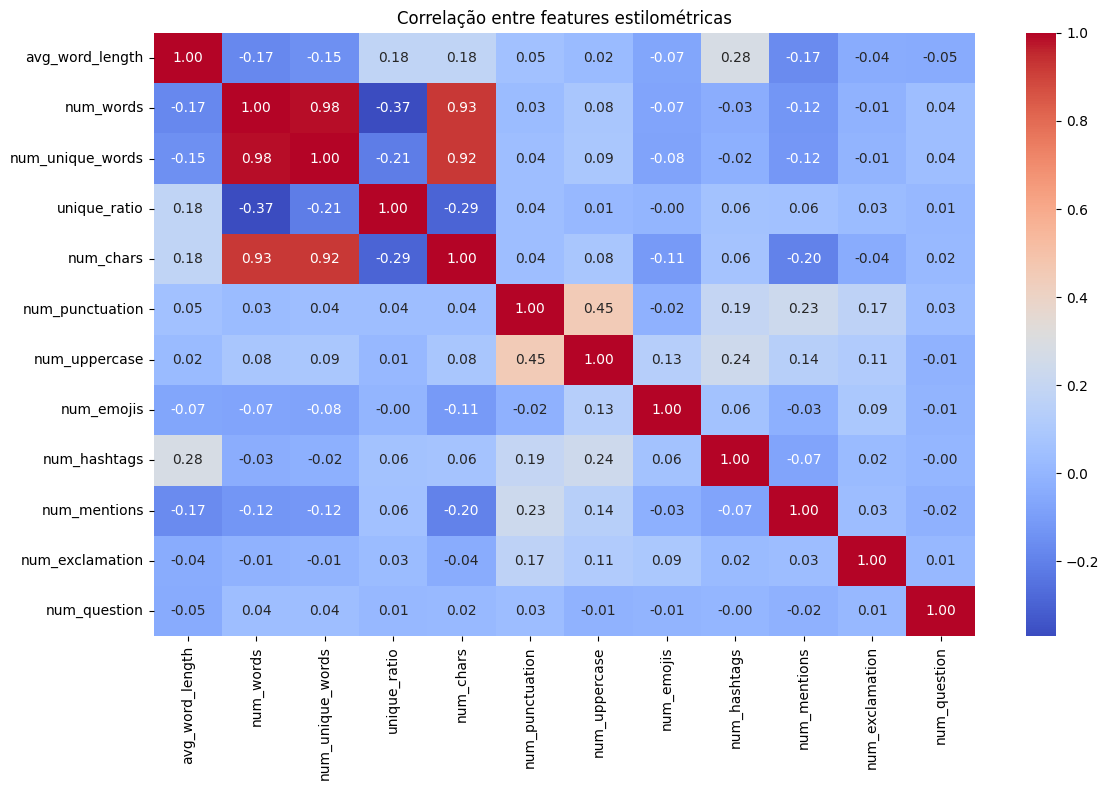

In [68]:
plt.figure(figsize=(12, 8))
sns.heatmap(features_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre features estilométricas")
plt.tight_layout()
plt.show()

In [69]:
x = features_df.reset_index(drop=True)
y= df["Name"].reset_index(drop=True)

print("x:", x.shape)
print("y:", y.shape)

y.value_counts()

x: (16912, 12)
y: (16912,)


Name
Barack Obama           2536
Neil deGrasse Tyson    2483
Ellen DeGeneres        2354
Sebastian Ruder        2197
KATY PERRY             1949
Kim Kardashian West    1901
Cristiano Ronaldo      1812
Elon Musk              1680
Name: count, dtype: int64

In [70]:
X_train, X_test, y_train, y_test = train_test_split (
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino", X_train.shape)
print("Teste:", X_test.shape)

Treino (13529, 12)
Teste: (3383, 12)


In [71]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [73]:
modelo_svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

modelo_svm.fit(X_train_scaled, y_train)

d:\PROJETO GB\Assinaturadigital-1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [74]:
modelo_nb = GaussianNB()

modelo_nb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](8,)","[2029.,1450.,1883.,...,1521.,1986.,1757.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](8,)","[0.15,0.11,0.14,...,0.11,0.15,0.13]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U19](8,)","['Barack Obama','Cristiano Ronaldo','Ellen DeGeneres',..., 'Kim Kardashian West','Neil deGrasse Tyson','Sebastian Ruder']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](8, 12)","[[ 0.51, 0.08, 0.09,...,-0.52,-0.36,-0.17], [-0.14,-0.17,-0.17,...,-0.2 , 0.31, 0.24], [-0.22,-0.19,-0.2 ,...,-0.03,-0. , 0.02], ..., [-0.41, 0.1 , 0.1 ,..., 0.07, 0.75,-0.06], [ 0.18, 0.41, 0.37,...,-0.21,-0.35, 0.06], [ 0.26, 0.15, 0.18,..., 0.53, 0.01, 0.08]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](8, 12)","[[0.72,0.59,0.58,...,0.34,0.03,0.27], [0.8 ,0.97,0.95,...,0.72,1.46,1.82], [0.86,0.91,0.91,...,0.68,0.64,1. ], ..., [0.66,1.3 ,1.3 ,...,0.76,3.62,1.39], [1.15,0.76,0.74,...,0.84,0.06,1.09], [1.1 ,0.88,0.9 ,...,1.42,0.67,1.24]]"


In [75]:
def avaliar_modelo(nome, modelo, X_test_scaled, y_test):
    y_pred = modelo.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    print(f"Modelo: {nome}")
    print(f"Acurácia: {acc:.4f}")
    print(f"F1 macro: {f1:.4f}")
    print()
    print(classification_report(y_test, y_pred))

    return{
        "modelo": nome,
        "acuracia": acc,
        "f1_macro": f1
    }

In [76]:
resultado_rf = avaliar_modelo("Random Forest", modelo_rf, X_test_scaled, y_test)
resultado_svm = avaliar_modelo("SVM", modelo_svm, X_test_scaled, y_test)
resultado_nb = avaliar_modelo("Naive Bayes", modelo_nb, X_test_scaled, y_test)

Modelo: Random Forest
Acurácia: 0.5004
F1 macro: 0.4889

                     precision    recall  f1-score   support

       Barack Obama       0.54      0.64      0.58       507
  Cristiano Ronaldo       0.37      0.25      0.30       362
    Ellen DeGeneres       0.43      0.53      0.47       471
          Elon Musk       0.48      0.44      0.46       336
         KATY PERRY       0.60      0.58      0.59       390
Kim Kardashian West       0.52      0.44      0.48       380
Neil deGrasse Tyson       0.59      0.59      0.59       497
    Sebastian Ruder       0.43      0.44      0.43       440

           accuracy                           0.50      3383
          macro avg       0.49      0.49      0.49      3383
       weighted avg       0.50      0.50      0.50      3383

Modelo: SVM
Acurácia: 0.5152
F1 macro: 0.5003

                     precision    recall  f1-score   support

       Barack Obama       0.55      0.71      0.62       507
  Cristiano Ronaldo       0.47      0.

In [77]:
resultados = pd.DataFrame([resultado_rf, resultado_svm, resultado_nb])

resultados = resultados.sort_values(by="f1_macro", ascending=False)

resultados

,modelo,acuracia,f1_macro
1,SVM,0.515223,0.500319
0,Random Forest,0.500443,0.488884
2,Naive Bayes,0.259237,0.214707


In [78]:
melhor_nome = resultados.iloc[0]["modelo"]

if melhor_nome == "Random Forest":
    melhor_modelo =modelo_rf
elif melhor_nome =="SVM":
    melhor_modelo = modelo_svm
else:
    melhor_modelo = modelo_nb

print("Melhor modelo:", melhor_nome)

Melhor modelo: SVM


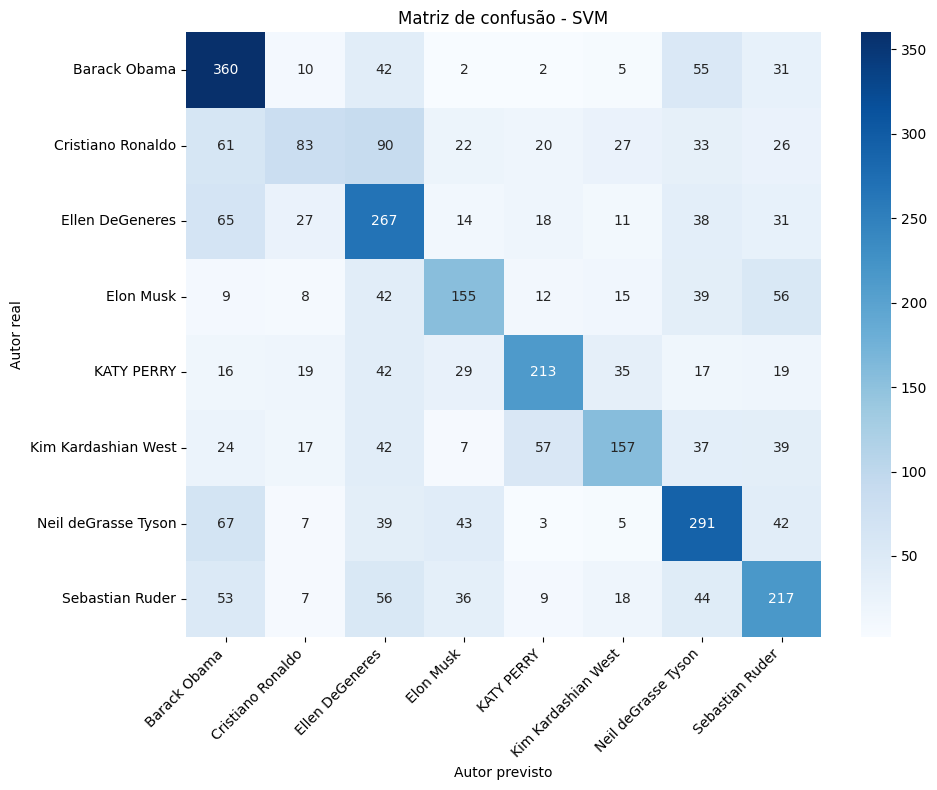

In [79]:
y_pred_melhor = melhor_modelo.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_melhor, labels=melhor_modelo.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=melhor_modelo.classes_,
    yticklabels=melhor_modelo.classes_,
    cmap="Blues"
)

plt.title(f"Matriz de confusão - {melhor_nome}")
plt.xlabel("Autor previsto")
plt.ylabel("Autor real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [81]:
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(melhor_modelo,  models_dir / "modelo_final.pkl")
joblib.dump(scaler, models_dir / "scaler.pkl")
joblib.dump(list(x.columns), models_dir / "features.pkl")

print("Arquivos salvos com sucesso:")
print(models_dir / "modelo_final.pkl")
print(models_dir / "scaler.pkl")
print(models_dir / "features.pkl")

Arquivos salvos com sucesso:
d:\PROJETO GB\Assinaturadigital-1\models\modelo_final.pkl
d:\PROJETO GB\Assinaturadigital-1\models\scaler.pkl
d:\PROJETO GB\Assinaturadigital-1\models\features.pkl


In [82]:
teste_modelo = joblib.load(ROOT / "models" / "modelo_final.pkl")
teste_scaler = joblib.load(ROOT / "models" / "scaler.pkl")
teste_features = joblib.load(ROOT / "models" / "features.pkl")

print(type(teste_modelo))
print(type(teste_scaler))
print(teste_features)

<class 'sklearn.svm._classes.SVC'>
<class 'sklearn.preprocessing._data.StandardScaler'>
['avg_word_length', 'num_words', 'num_unique_words', 'unique_ratio', 'num_chars', 'num_punctuation', 'num_uppercase', 'num_emojis', 'num_hashtags', 'num_mentions', 'num_exclamation', 'num_question']
